# Brake and tyre wear from petrol cars in Kingston (LAEI 2022)

* Author: Andrew Sivanesan
* Date: 1st Feb 2026

## Executive summary

TBC

## Background

TBC

* Add details about TfL's Sustainability plan
* Kingston Climate Action Strategy (2024 to 2030). Theme 2 (How we travel) (pp.18 and 19) (link [here](https://www.kingston.gov.uk/sites/default/files/downloads/Climate_Action_Strategy_24_30_accessible_.pdf)]
* Kingston Air Quality Action Plan (2021 to 2026) (link [here](https://www.kingston.gov.uk/sites/default/files/2025-05/Kingston_Air_Quality_Action_Plan_2021___2026__Aug___1_.pdf))
* Study on non-exhaust emissions (NEE) in road transport (EIT Urban Mobility) (link [here](https://www.eiturbanmobility.eu/knowledge-hub/non-exhaust-emission-study/?utm_source=linkedin&utm_medium=organic&utm_campaign=promotion_2205))
* Euro 7 emissions standard (link [here](https://www.consilium.europa.eu/en/press/press-releases/2024/04/12/euro-7-council-adopts-new-rules-on-emission-limits-for-cars-vans-and-trucks/))
* World Health Organisation (WHO) global air quality guidelines 2021 (link [here](https://iris.who.int/server/api/core/bitstreams/b729bbc4-7032-4799-898e-d112faa16f22/content))
* Include health impacts of brake wear particles


## Sources

* London Atmospheric Emissions Inventory 2022 (grid emissions summary). London Datastore (link [here](https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g/))
* May 2025 Local Authority District (LAD) boundaries (filtered for Kingston Upon Thames). Open Geography Portal - Office for National Statistics. (link [here](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2025-boundaries-uk-bfc-v2/explore?filters=eyJMQUQyNU5NIjpbIktpbmdzdG9uIHVwb24gVGhhbWVzIl0sIlNoYXBlX19BcmVhIjpbMjg4OTY3OS41Mjg0MzQ3NTM0LDI2MTU4NjY5Nzc0Ljk1MjYzN10sIlNoYXBlX19MZW5ndGgiOls5NDA0LjcxODk3MzQxNTg5Myw1MjM3NTA3LjM1ODU0MDQ2OF19&location=55.340000%2C-3.316939%2C5))
* Transport for London (TfL)'s air quality page (link [here](https://tfl.gov.uk/corporate/about-tfl/air-quality)))
* Questions to the Mayor about car emissions - 9th Oct 2025 (link [here](https://www.london.gov.uk/who-we-are/what-london-assembly-does/questions-mayor/find-an-answer/car-emissions#:~:text=Answer&text=Please%20find%20information%20on%20cars,2025%20(the%20latest%20available))

## Credits

* Python Graph Gallery (link [here](python-graph-gallery.com))

## Use of generative AI

Google Gemini was used to answer questions about Python coding syntax and geospatial data visualisation as well as contextual questions about London air quality. I confirmed accuracy of responses by viewing the source web pages.

FixMe(20260219)

* Focus this analysis on **non-exhaust emissions from petrol cars** (brake wear and tyre wear - pm10 and pm2.5) given its relevance to Euro 7 emissions standard (taking effect from 29th Nov 2026). Use LAEI2022-nox-pm-co2-minor-roads-grid-emissions.xlsx spreadsheet (or try using the GIS file).
* Calculate pm10 brake wear emissions per vehicle kilometre (petrol cars) - use **LAEI2022-minor-roads-flows-and-speeds.xlsx** spreadsheet
* Highlight if any schools are in the identified hotspots (given the risk to child health from poor air quality).
* Customise the choropleth map (e.g. title, annotations, legend) to maximise clarity.

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import geopandas as gpd
import numpy as np

## Data preparation

In [56]:
# define the name of the files to be read into this notebook
fname_emissionsgrid = "EmissionsByGridID_2022to2030.csv"
fname_boundary = "KingstonUponThamesBoundary.geojson"
fname_emissions = "LAEI2022-nox-pm-co2-minor-roads-grid-emissions.xlsx"
fname_flows = "LAEI2022-minor-roads-flows-and-speeds.xlsx"

In [ ]:
flows = pd.read_excel(fname_flows)

In [61]:
cond = (flows["year"] == 2022) & (flows["borough"] == "Kingston")
cols = ["grid.id.1km2", "vkm.cars"]

kingston_car_flows = flows[cond][cols]

kingston_car_flows.head()

,grid.id.1km2,vkm.cars
870,11253,3.256694e+05
901,11593,9.349448e+05
902,11595,4.665648e+06
905,11597,1.895619e+06
941,11937,1.796293e+06


In [ ]:
grid_emissions = pd.read_excel(fname_emissions)

In [27]:
cond = (grid_emissions["year"] == 2022) & (grid_emissions["borough"] == "Kingston") & (grid_emissions["pm-source"].isin(["Brake", "Tyre"]))

cols = ["grid.id.1km2", "pollutant", "pm-source", "Road-Car-Petrol"]

kingston_petrol_cars = grid_emissions[cond][cols]

In [28]:
# read in Kingston LAEI grid squares shapefile
grid_boundaries = gpd.read_file("LAEI2019_grid.shp")
grid_boundaries = grid_boundaries[grid_boundaries["Borough"] == "Kingston"]
#grid_boundaries.head()

In [92]:
# columns to select
cols = ["1km2_ID", "geometry", "pollutant", "pm-source", "Road-Car-Petrol", "vkm.cars"]

# right join is used instead of left join to ensure that the output is a GeoDataFrame rather than a Pandas DataFrame. 
# This is necessary for plotting a choropleth map in Folium in the next step.
kingston_petrol_cars_grid = (grid_boundaries.merge(kingston_petrol_cars, how="right", left_on="1km2_ID", right_on="grid.id.1km2")
                                            .merge(kingston_car_flows, how="right", left_on="1km2_ID", right_on="grid.id.1km2")[cols])

kingston_petrol_cars_grid["pm10_brake_per_vkm_scaled"] = 1000000000000 * (kingston_petrol_cars_grid["Road-Car-Petrol"] / kingston_petrol_cars_grid["vkm.cars"])

kingston_petrol_cars_grid.head()

,1km2_ID,geometry,pollutant,pm-source,Road-Car-Petrol,vkm.cars,pm10_brake_per_vkm_scaled
0,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",pm10,Brake,0.008818,325669.410205,27075.097728
1,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",pm10,Tyre,0.002151,325669.410205,6603.440267
2,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",pm2.5,Brake,0.003509,325669.410205,10774.783790
3,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",pm2.5,Tyre,0.001505,325669.410205,4622.408187
4,11593,"POLYGON ((518000 169999.997, 517777.903 169999...",pm10,Brake,0.025314,934944.758420,27075.097813


In [102]:
cond_pm10_brake = (kingston_petrol_cars_grid["pollutant"] == "pm10") & (kingston_petrol_cars_grid["pm-source"] == "Brake") & (kingston_petrol_cars_grid["vkm.cars"] > 0.0)

pm10_brake = kingston_petrol_cars_grid[cond_pm10_brake]

pm10_brake

,1km2_ID,geometry,pollutant,pm-source,Road-Car-Petrol,vkm.cars,pm10_brake_per_vkm_scaled
0,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",pm10,Brake,0.008818,3.256694e+05,27075.097728
4,11593,"POLYGON ((518000 169999.997, 517777.903 169999...",pm10,Brake,0.025314,9.349448e+05,27075.097813
8,11595,"POLYGON ((519999.996 169999.997, 519000.002 16...",pm10,Brake,0.126323,4.665648e+06,27075.097563
12,11597,"POLYGON ((521812.401 169999.997, 520999.998 16...",pm10,Brake,0.051324,1.895619e+06,27075.097202
16,11937,"POLYGON ((518000 168000, 517565.378 168000, 51...",pm10,Brake,0.048635,1.796293e+06,27075.098535
20,11939,"POLYGON ((519999.996 168000, 519000.002 168000...",pm10,Brake,0.163176,6.026790e+06,27075.098300
24,11941,"POLYGON ((522000.001 168000, 520999.998 168000...",pm10,Brake,0.191093,7.057905e+06,27075.098564
28,12282,"POLYGON ((519000.002 166000.002, 518000 166000...",pm10,Brake,0.180213,6.656049e+06,27075.097724
32,12284,"POLYGON ((520999.998 166000.002, 519999.996 16...",pm10,Brake,0.179390,6.625663e+06,27075.097356
36,12286,"POLYGON ((522231.101 166014.998, 522197.998 16...",pm10,Brake,0.105642,3.901815e+06,27075.098008


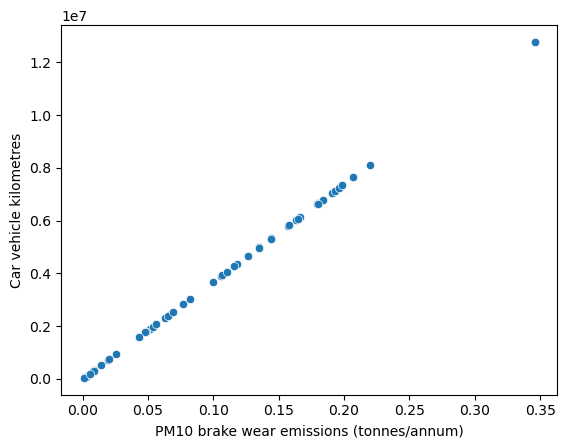

In [103]:
# Linear relationship, and perfect positive correlation, between PM10 brake wear emissions and car vehicle kilometres
sns.scatterplot(data=pm10_brake, x="Road-Car-Petrol", y="vkm.cars")
plt.xlabel("PM10 brake wear emissions (tonnes/annum)")
plt.ylabel("Car vehicle kilometres")
plt.show()

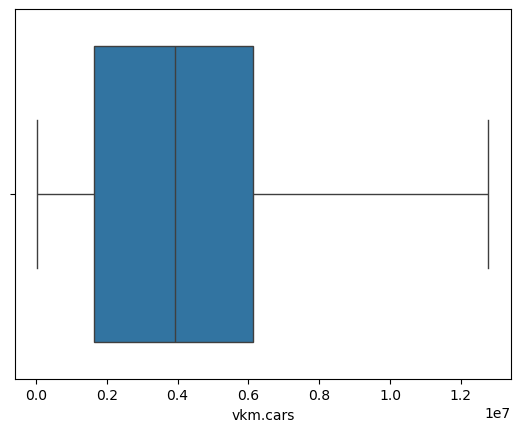

In [104]:
sns.boxplot(data=pm10_brake, x="vkm.cars")
plt.show()

In [106]:
kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=11)

# plot Kingston boundary
folium.GeoJson(fname_boundary, name="Kingston boundary").add_to(m1)

# PM10 brake wear emissions hotspot near the intersection of B280 Fairoak Lane and A243 Leatherhead Road
# This is close to Chessington World of Adventures: a theme park that's popular with young families
folium.Choropleth(
    geo_data=pm10_brake,
    data=pm10_brake,
    key_on="feature.properties.1km2_ID",
    name="PM10 brake wear",
    columns=["1km2_ID", "Road-Car-Petrol"],
    fill_color="viridis",
    legend_name="PM10 brake wear (tonnes/annum)"
).add_to(m1)

m1

In [69]:
m2 = folium.Map(location=kingston_coords, zoom_start=11)

# plot Kingston boundary
folium.GeoJson(fname_boundary, name="Kingston boundary").add_to(m2)

# Traffic hotspot near the intersection of B280 Fairoak Lane and A243 Leatherhead Road
# This is close to Chessington World of Adventures: a theme park that's popular with young families
folium.Choropleth(
    geo_data=pm10_brake,
    data=pm10_brake,
    key_on="feature.properties.1km2_ID",
    name="Car vehicle kilometres (vkm)",
    columns=["1km2_ID", "vkm.cars"],
    fill_color="viridis",
    legend_name="Car vehicle kilometres"
).add_to(m2)

m2

## Delete the cells below relating to CO2 emissions

In [44]:
# read in the file (whole of London)
df = pd.read_csv(fname_emissionsgrid)

In [45]:
# define filter condition
cond = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Sector"] == "Road Transport")

# filter the data
kingston_road_transport = df[cond].copy()

## Exploratory data analysis (all Kingston road transport emissions for 2022)

* Looking at the mean, median, upper quartile and maximum values: **carbon dioxide (co2)** is by far the largest of all the pollutants (in terms of tonnes per annum)
* There are multiple pollutants for which we have no data (e.g. bap, cd, c4h6 etc.)
* **All the pollutants are strongly positively correlated with each other**. Therefore we can reasonably focus the analysis on CO2 as a proxy for emissions across all pollutants. Any reduction in CO2 emissions will reduce emissions of all other pollutants.
* There are **1,545 rows** of Kingston road transport data.
* All columns are fully populated i.e. there are **no missing values.**
* **Petrol cars** have by far the greatest median annual carbon dioxide (CO2) emissions (874 tonnes per annum) of all types of road vehicle. This is most likely because, according to the London Assembly, **petrol cars constituted 66% of cars licensed in London at the end of 2020.**

In [46]:
pollutant_cols = ['bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'co2', 'hc', 'hcl', 'hg', 'n2o', 'nh3', 'nmvoc', 'nox', 'pb', 'pcb', 'pm10', 'pm2.5', 'so2']

kingston_road_transport[pollutant_cols].describe()

,bap,cd,c4h6,c6h6,ch4,co,co2,hc,hcl,hg,n2o,nh3,nmvoc,nox,pb,pcb,pm10,pm2.5,so2
count,0.0,0.0,0.0,0.0,885.000000,0.0,885.000000,0.0,0.0,0.0,885.000000,0.0,0.0,885.000000,0.0,0.0,885.000000,885.000000,0.0
mean,NaN,NaN,NaN,NaN,0.007166,NaN,193.111507,NaN,NaN,NaN,0.006342,NaN,NaN,0.351772,NaN,NaN,0.063597,0.030650,NaN
std,NaN,NaN,NaN,NaN,0.017247,NaN,475.144294,NaN,NaN,NaN,0.014769,NaN,NaN,0.881882,NaN,NaN,0.154698,0.074069,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000157,NaN,NaN,0.001194,0.000595,NaN
50%,NaN,NaN,NaN,NaN,0.000298,NaN,23.514260,NaN,NaN,NaN,0.000733,NaN,NaN,0.028583,NaN,NaN,0.007006,0.003601,NaN
75%,NaN,NaN,NaN,NaN,0.001925,NaN,144.500248,NaN,NaN,NaN,0.005167,NaN,NaN,0.212111,NaN,NaN,0.040372,0.019270,NaN
max,NaN,NaN,NaN,NaN,0.130145,NaN,4707.255276,NaN,NaN,NaN,0.134449,NaN,NaN,7.940952,NaN,NaN,1.411963,0.666482,NaN


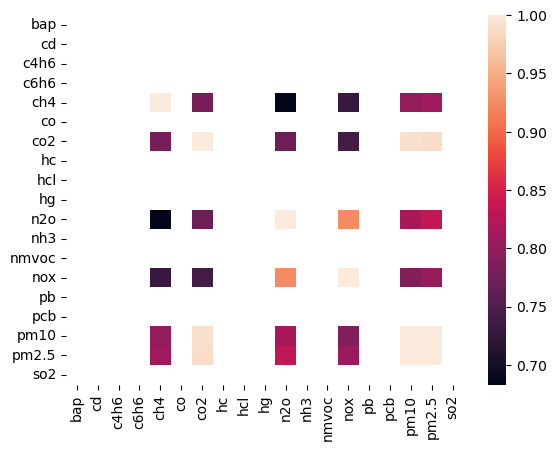

In [47]:
# Calculate the correlation matrix for the pollutants
corr = kingston_road_transport[pollutant_cols].corr()

# plot the correlation heatmap
# correlations between 0.7 and 1 i.e. strong positive correlation between pollutants
sns.heatmap(corr)
plt.show()

In [48]:
# define the columns to select
cols = ["LAEI 1km2 ID", "Source", "co2", "Emissions Unit"]

# apply filters and select columns
kingston_road_transport = kingston_road_transport[cols]

#kingston_road_transport.head()

In [49]:
kingston_road_transport.describe()

,LAEI 1km2 ID,co2
count,885.000000,885.000000
mean,12236.118644,193.111507
std,589.241846,475.144294
min,11252.000000,0.000000
25%,11767.000000,0.000000
50%,12114.000000,23.514260
75%,12628.000000,144.500248
max,13484.000000,4707.255276


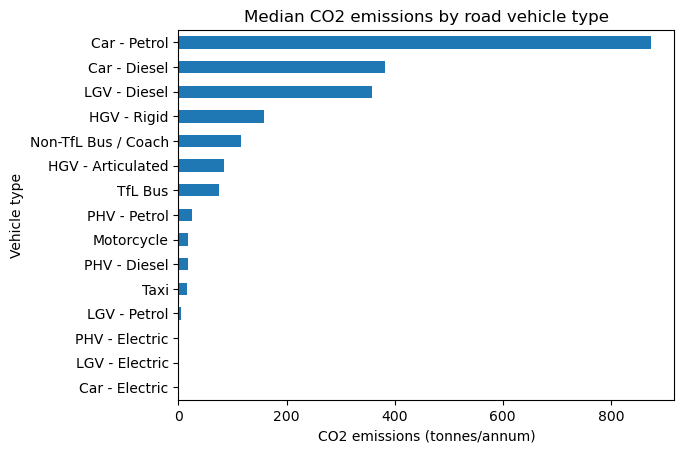

In [50]:
kingston_road_transport.groupby("Source")["co2"].median().sort_values().plot.barh(y="Source")
plt.title("Median CO2 emissions by road vehicle type")
plt.xlabel("CO2 emissions (tonnes/annum)")
plt.ylabel("Vehicle type")
plt.show()

## Exploratory data analysis (petrol cars)

* CO2 emissions for petrol cars is right-skewed. There are **four grid squares with outlier CO2 emissions (more than 4,000 tonnes per annum)**. Note: there are **four grid squares where CO2 emissions for petrol cars is zero.**

In [51]:
cols = ["LAEI 1km2 ID", "co2", "Emissions Unit"]

kingston_petrol_cars = kingston_road_transport[kingston_road_transport["Source"] == "Car - Petrol"][cols]
kingston_petrol_cars["Legend"] = "Kingston"

In [52]:
kingston_petrol_cars.isnull().sum()

LAEI 1km2 ID      0
co2               0
Emissions Unit    0
Legend            0
dtype: int64

In [53]:
kingston_petrol_cars.describe()

,LAEI 1km2 ID,co2
count,59.000000,59.000000
mean,12236.118644,1169.595821
std,593.963951,1169.662386
min,11252.000000,0.000000
25%,11767.500000,321.778195
50%,12114.000000,873.818508
75%,12627.500000,1529.100721
max,13484.000000,4707.255276


## Compare Kingston to London as a whole

In [54]:
cond = (df["Year"] == 2022) & (df["Source"] == "Car - Petrol")

cols = ["LAEI 1km2 ID", "Borough", "co2"]

london_petrol_cars = df[cond][cols]
london_petrol_cars["Legend"] = "London"

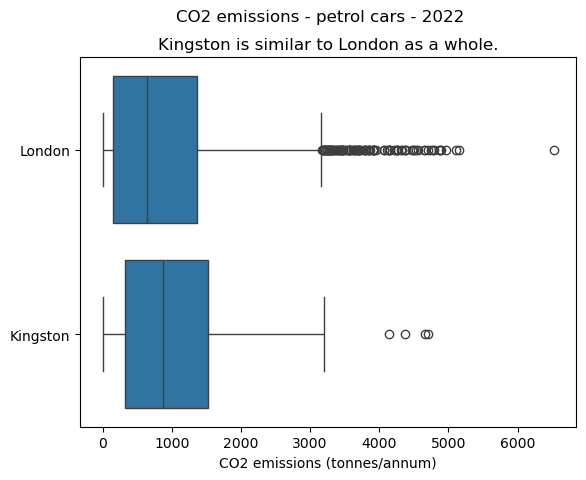

In [55]:
boxplot_df = pd.concat([london_petrol_cars, kingston_petrol_cars])

sns.boxplot(data=boxplot_df, x="co2", y="Legend")
plt.suptitle("CO2 emissions - petrol cars - 2022")
plt.title("Kingston is similar to London as a whole.")
plt.xlabel("CO2 emissions (tonnes/annum)")
plt.ylabel("")
plt.show()

## Visualise the emissions data

In [56]:
# read in Kingston LAEI grid squares shapefile
grid_boundaries = gpd.read_file("LAEI2019_grid.shp")
grid_boundaries = grid_boundaries[grid_boundaries["Borough"] == "Kingston"]
#grid_boundaries.head()

In [58]:
# columns to select
cols = ["LAEI 1km2 ID", "geometry", "co2"]

# right join is used instead of left join to ensure that the output is a GeoDataFrame rather than a Pandas DataFrame. 
# This is necessary for plotting a choropleth map in Folium in the next step.
kingston_petrol_cars_grid = grid_boundaries.merge(kingston_petrol_cars, how="right", left_on="1km2_ID", right_on="LAEI 1km2 ID")[cols]

In [59]:
kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=11)

# plot Kingston boundary
folium.GeoJson(fname_boundary).add_to(m1)

# CO2 hotspots on Kingston Bypass/Hook Rise South, Tolworth Junction, Malden Junction and the Bentall Centre
# Junctions and town centres are typically hotspots for traffic jams and engine idling.

folium.Choropleth(
    geo_data=kingston_petrol_cars_grid,
    data=kingston_petrol_cars_grid,
    key_on="feature.properties.LAEI 1km2 ID",
    name="choropleth",
    bins=[0, 1000, 2000, 3000, 4000, 5000],
    columns=["LAEI 1km2 ID", "co2"],
    fill_color="viridis",
    legend_name="CO2 emissions (tonnes/annum)"
).add_to(m1)

m1

In [64]:
road_flow = pd.read_excel(fname_roadflows)

cond = (road_flow["year"] == 2022) & (road_flow["borough"] == "Kingston")

cols = ["grid.id.1km2", "vkm.tfl.buses", "vkm.non.tfl.buses"]

kingston_bus_flow = road_flow[cond][cols]

# columns to select
cols = ["1km2_ID", "geometry", "vkm.tfl.buses", "vkm.non.tfl.buses"]

bus_flows_grid = grid_boundaries.merge(kingston_bus_flow, how="right", left_on="1km2_ID", right_on="grid.id.1km2")[cols]
bus_flows_grid["vkm.all.buses"] = bus_flows_grid["vkm.tfl.buses"] + bus_flows_grid["vkm.non.tfl.buses"]
bus_flows_grid

,1km2_ID,geometry,vkm.tfl.buses,vkm.non.tfl.buses,vkm.all.buses
0,11253,"POLYGON ((521663.479 172000.005, 520999.998 17...",4650.731120,1813.289337,6464.020457
1,11593,"POLYGON ((518000 169999.997, 517777.903 169999...",13351.504769,5205.663499,18557.168268
2,11595,"POLYGON ((519999.996 169999.997, 519000.002 16...",66627.917957,25977.785016,92605.702974
3,11597,"POLYGON ((521812.401 169999.997, 520999.998 16...",27070.444567,10554.587488,37625.032055
4,11937,"POLYGON ((518000 168000, 517565.378 168000, 51...",25652.019108,10001.552773,35653.571881
5,11939,"POLYGON ((519999.996 168000, 519000.002 168000...",86065.742363,33556.464331,119622.206694
6,11941,"POLYGON ((522000.001 168000, 520999.998 168000...",100790.607843,39297.592098,140088.199940
7,12282,"POLYGON ((519000.002 166000.002, 518000 166000...",95051.895054,37060.105896,132112.000950
8,12284,"POLYGON ((520999.998 166000.002, 519999.996 16...",94617.961072,36890.917903,131508.878975
9,12286,"POLYGON ((522231.101 166014.998, 522197.998 16...",55719.981894,21724.852812,77444.834705


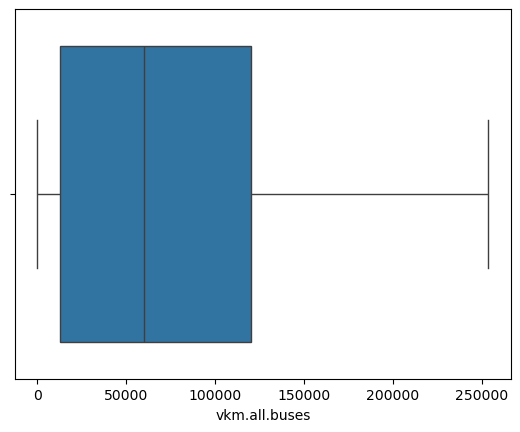

In [66]:
sns.boxplot(data=bus_flows_grid, x="vkm.all.buses")
plt.show()

In [68]:
m2 = folium.Map(location=kingston_coords, zoom_start=11)

# plot Kingston boundary
folium.GeoJson(fname_boundary).add_to(m2)

# CO2 hotspots on Kingston Bypass/Hook Rise South, Tolworth Junction, Malden Junction and the Bentall Centre
# Junctions and town centres are typically hotspots for traffic jams and engine idling.

folium.Choropleth(
    geo_data=bus_flows_grid,
    data=bus_flows_grid,
    key_on="feature.properties.1km2_ID",
    name="choropleth",
    columns=["1km2_ID", "vkm.all.buses"],
    bins=5,
    fill_color="viridis",
    legend_name="Bus vehicle kilometres (TfL and non-TfL)"
).add_to(m2)

m2

In [18]:
pm10_brake_layer = "pm10-brake-wear-major-roads-link-emissions"
pm10_tyre_layer = "pm10-tyre-wear-major-roads-link-emissions"
pm2_5_brake_layer = "pm2.5-brake-wear-major-roads-link-emissions"
pm2_5_tyre_layer = "pm2.5-tyre-wear-major-roads-link-emissions"

pm10_brake = gpd.read_file(fname_link_emissions, layer=pm10_brake_layer)
pm10_tyre = gpd.read_file(fname_link_emissions, layer=pm10_tyre_layer)
pm2_5_brake_layer = gpd.read_file(fname_link_emissions, layer=pm2_5_brake_layer)
pm2_5_tyre_layer = gpd.read_file(fname_link_emissions, layer=pm2_5_tyre_layer)

In [19]:
pm10_brake.columns

Index(['TOID', 'pollutant', 'pm-source', 'emissions-units',
       'Road-Car-Petrol-2022', 'Road-Car-Diesel-2022',
       'Road-Car-Electric-2022', 'Road-PHV-Petrol-2022',
       'Road-PHV-Diesel-2022', 'Road-PHV-Electric-2022',
       'Road-LGV-Petrol-2022', 'Road-LGV-Diesel-2022',
       'Road-LGV-Electric-2022', 'Road-HGV-Rigid-2022',
       'Road-HGV-Articulated-2022', 'Road-TfL-Bus-2022',
       'Road-Non-TfL-Bus-or-Coach-2022', 'Road-Taxi-2022',
       'Road-Motorcycle-2022', 'Road-Total-2022', 'geometry'],
      dtype='object')

In [12]:
m3 = folium.Map(location=kingston_coords, zoom_start=11)

# plot Kingston boundary
folium.GeoJson(fname_boundary).add_to(m3)

# CO2 hotspots on Kingston Bypass/Hook Rise South, Tolworth Junction, Malden Junction and the Bentall Centre
# Junctions and town centres are typically hotspots for traffic jams and engine idling.

folium.Choropleth(
    geo_data=pm10_brake,
    data=bus_pm10_brake,
    key_on="feature.properties.TOID",
    name="choropleth",
    columns=["TOID", "Road-Car-Petrol-2022"],
    fill_color="viridis",
    legend_name="PM10 brake wear"
).add_to(m3)

m3

NameError: name 'kingston_coords' is not defined